In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
data_path = os.path.join("..", "data", "diabetes.csv")
df = pd.read_csv(data_path)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("Shape:", df.shape)

Shape: (768, 9)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [ ]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

EDA


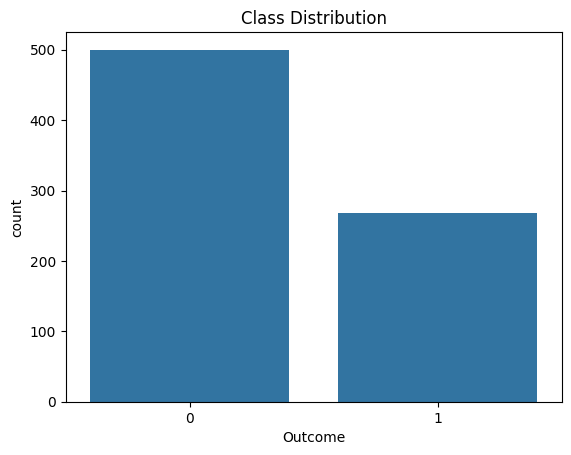

In [ ]:
sns.countplot(x='Outcome', data=df)
plt.title("Class Distribution")
plt.show()
# SMOTE ~70(1)

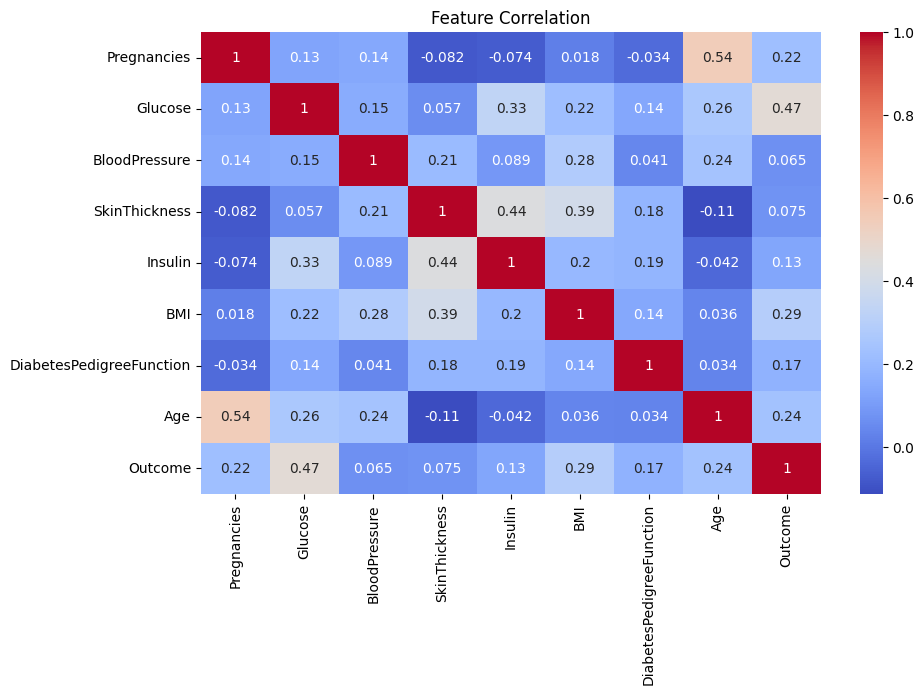

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

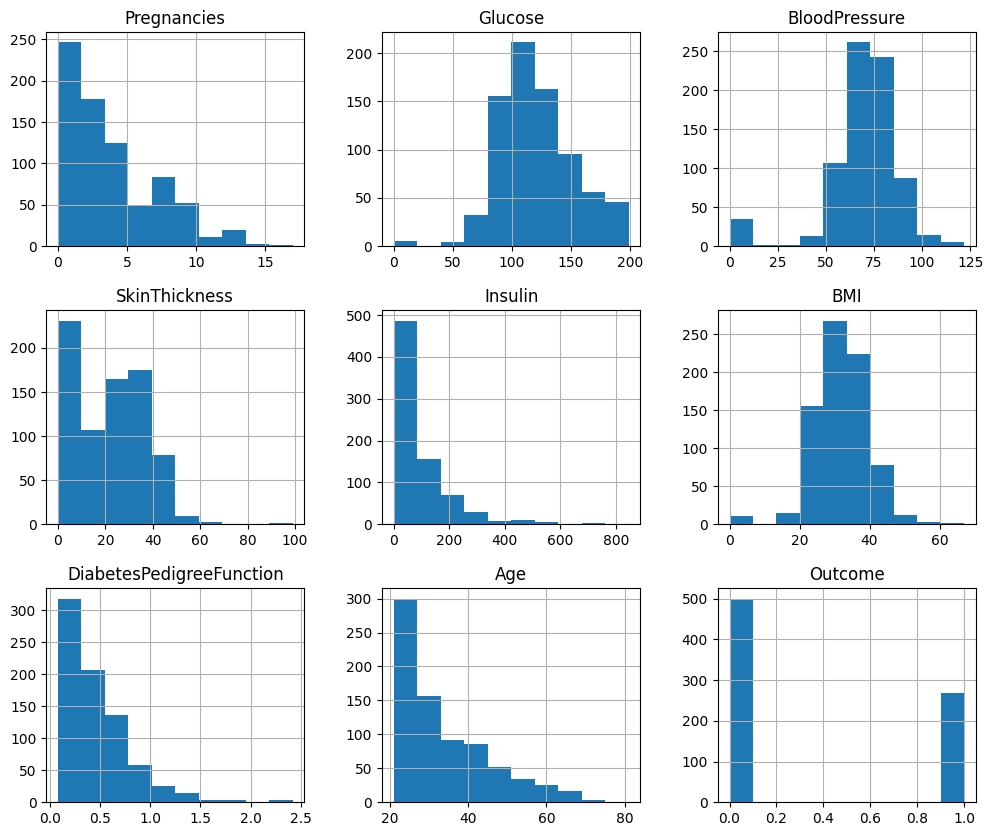

In [ ]:
df.hist(figsize=(12,10))
plt.show()

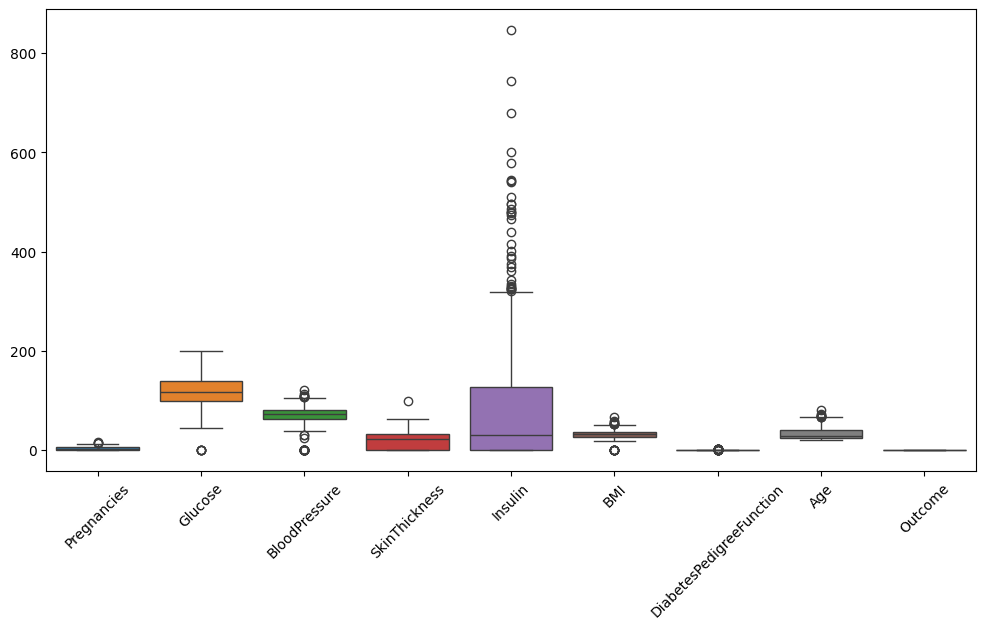

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

Data Preprocessing

In [ ]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [ ]:
(df == 0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

In [ ]:
# from sklearn.linear_model import LogisticRegression

# model = LogisticRegression()
# model.fit(X_train, y_train)

In [ ]:
#CLASS WEIGHTS
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
#prediction
y_pred = model.predict(X_test)

In [ ]:
#evaluation
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7272727272727273


In [ ]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.74      0.78       100
           1       0.59      0.70      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



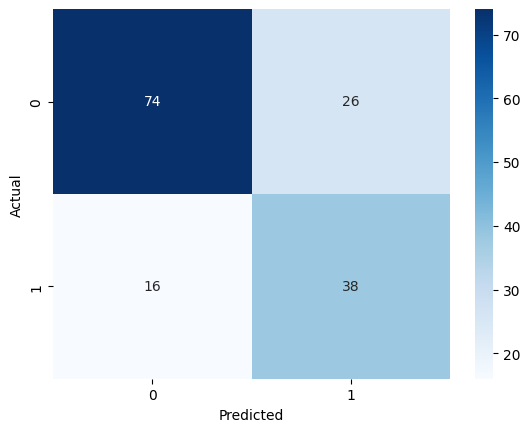

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#random forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       100
           1       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



FEATURE IMPORTANCE

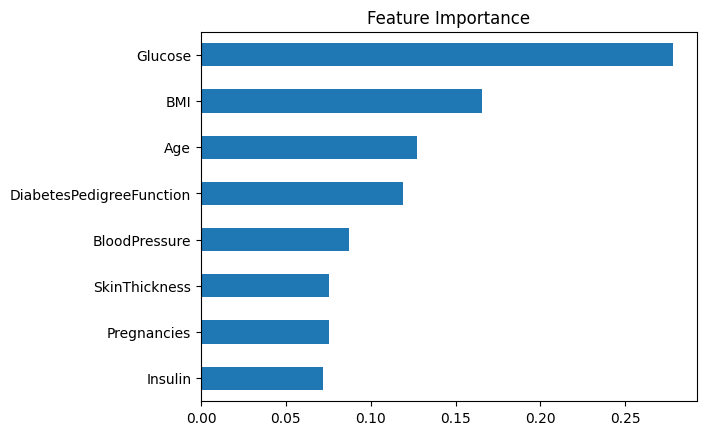

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feat_imp = pd.Series(importance, index=X.columns)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# STEP 1: Get probability scores
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# STEP 2: Apply new threshold
y_pred_new = (y_prob_rf > 0.4).astype(int)

Classification Report (Threshold = 0.4):

              precision    recall  f1-score   support

           0       0.82      0.75      0.78       100
           1       0.60      0.69      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



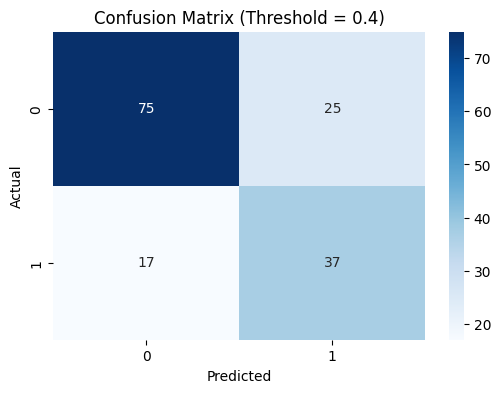

In [ ]:
#evaluation
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Classification Report (Threshold = 0.4):\n")
print(classification_report(y_test, y_pred_new))

cm = confusion_matrix(y_test, y_pred_new)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Threshold = 0.4)")
plt.show()

In [ ]:
#xg boost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

/home/acer/Downloads/credit-card-fraud-detection/venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [23:39:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
#evaluate
from sklearn.metrics import classification_report, confusion_matrix

print("XGBoost Report:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost Report:

              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.62      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



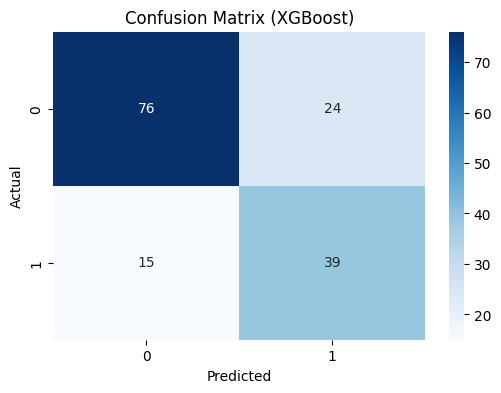

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (XGBoost)")
plt.show()

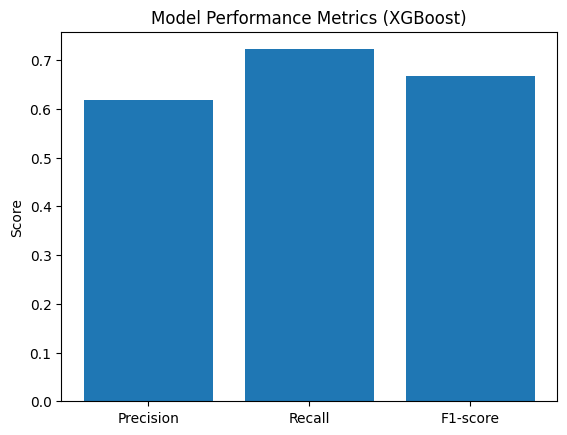

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

metrics = ['Precision', 'Recall', 'F1-score']
values = [precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance Metrics (XGBoost)")
plt.ylabel("Score")
plt.show()

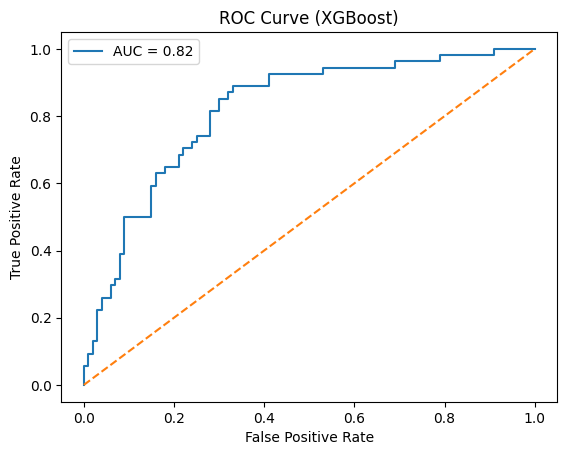

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get probabilities
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (XGBoost)")
plt.legend()
plt.show()

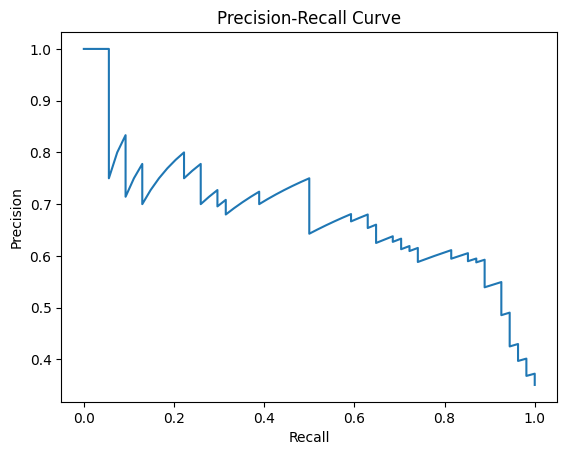

In [ ]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

threshold optimization

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# STEP 1: Get probabilities
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# STEP 2: Try multiple thresholds
thresholds = np.arange(0.1, 0.9, 0.05)

print("Threshold Optimization Results:\n")

for t in thresholds:
    y_pred_temp = (y_prob > t).astype(int)
    
    precision = precision_score(y_test, y_pred_temp)
    recall = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)
    
    print(f"Threshold: {t:.2f} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}")

Threshold Optimization Results:

Threshold: 0.10 | Precision: 0.48 | Recall: 0.94 | F1: 0.64
Threshold: 0.15 | Precision: 0.53 | Recall: 0.93 | F1: 0.67
Threshold: 0.20 | Precision: 0.54 | Recall: 0.93 | F1: 0.68
Threshold: 0.25 | Precision: 0.56 | Recall: 0.89 | F1: 0.69
Threshold: 0.30 | Precision: 0.59 | Recall: 0.89 | F1: 0.71
Threshold: 0.35 | Precision: 0.59 | Recall: 0.87 | F1: 0.70
Threshold: 0.40 | Precision: 0.61 | Recall: 0.85 | F1: 0.71
Threshold: 0.45 | Precision: 0.60 | Recall: 0.74 | F1: 0.66
Threshold: 0.50 | Precision: 0.62 | Recall: 0.72 | F1: 0.67
Threshold: 0.55 | Precision: 0.63 | Recall: 0.69 | F1: 0.65
Threshold: 0.60 | Precision: 0.66 | Recall: 0.65 | F1: 0.65
Threshold: 0.65 | Precision: 0.67 | Recall: 0.61 | F1: 0.64
Threshold: 0.70 | Precision: 0.66 | Recall: 0.50 | F1: 0.57
Threshold: 0.75 | Precision: 0.74 | Recall: 0.46 | F1: 0.57
Threshold: 0.80 | Precision: 0.70 | Recall: 0.35 | F1: 0.47
Threshold: 0.85 | Precision: 0.71 | Recall: 0.31 | F1: 0.44


In [ ]:
best_threshold = 0.30

y_pred_final = (y_prob > best_threshold).astype(int)

evaluation

Final Model (Threshold = 0.30):

              precision    recall  f1-score   support

           0       0.92      0.66      0.77       100
           1       0.59      0.89      0.71        54

    accuracy                           0.74       154
   macro avg       0.75      0.77      0.74       154
weighted avg       0.80      0.74      0.75       154



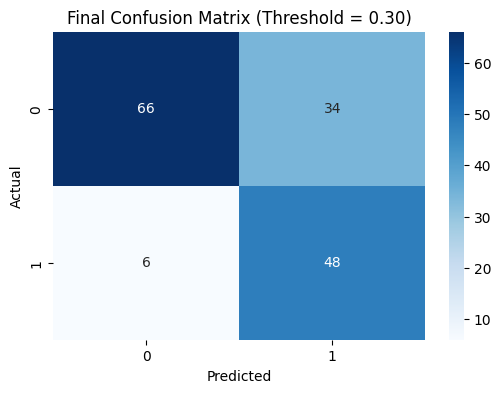

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Final Model (Threshold = 0.30):\n")
print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Final Confusion Matrix (Threshold = 0.30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
best_threshold = 0.35

y_pred_final = (y_prob > best_threshold).astype(int)

Final Model (Threshold = 0.30):

              precision    recall  f1-score   support

           0       0.91      0.67      0.77       100
           1       0.59      0.87      0.70        54

    accuracy                           0.74       154
   macro avg       0.75      0.77      0.74       154
weighted avg       0.79      0.74      0.75       154



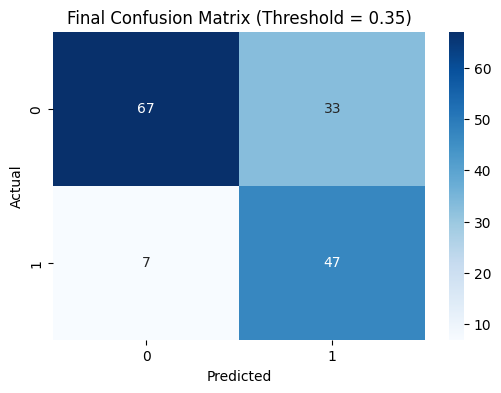

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Final Model (Threshold = 0.30):\n")
print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Final Confusion Matrix (Threshold = 0.35)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
best_threshold = 0.40

y_pred_final = (y_prob > best_threshold).astype(int)

Final Model (Threshold = 0.30):

              precision    recall  f1-score   support

           0       0.90      0.70      0.79       100
           1       0.61      0.85      0.71        54

    accuracy                           0.75       154
   macro avg       0.75      0.78      0.75       154
weighted avg       0.79      0.75      0.76       154



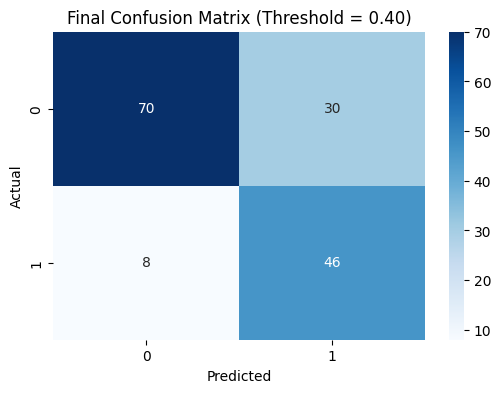

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Final Model (Threshold = 0.30):\n")
print(classification_report(y_test, y_pred_final))
crXG = classification_report(y_test, y_pred_final)
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Final Confusion Matrix (Threshold = 0.40)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import os
# .4  `Threshoold`

In [ ]:
import pandas as pd

data = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost (Threshold = 0.40)"
    ],
    
    "Accuracy": [
        0.73,
        0.72,
        0.75
    ],
    
    "Recall (Diabetic)": [
        0.70,
        0.69,
        0.85
    ],
    
    "Precision (Diabetic)": [
        0.59,
        0.60,
        0.61
    ],
    
    "F1-score": [
        0.64,
        0.64,
        0.71
    ]
}

df_compare = pd.DataFrame(data)
df_compare

,Model,Accuracy,Recall (Diabetic),Precision (Diabetic),F1-score
0,Logistic Regression,0.73,0.70,0.59,0.64
1,Random Forest,0.72,0.69,0.60,0.64
2,XGBoost (Threshold = 0.40),0.75,0.85,0.61,0.71


In [ ]:
print(crXG)

              precision    recall  f1-score   support

           0       0.90      0.70      0.79       100
           1       0.61      0.85      0.71        54

    accuracy                           0.75       154
   macro avg       0.75      0.78      0.75       154
weighted avg       0.79      0.75      0.76       154



feature engineering

In [ ]:
# Make a copy (safe practice)
df_fe = df.copy()

# 1. BMI Category (health important)
df_fe['BMI_Category'] = pd.cut(df_fe['BMI'],
                              bins=[0, 18.5, 25, 30, 100],
                              labels=[0, 1, 2, 3])  
# 0=Underweight, 1=Normal, 2=Overweight, 3=Obese


# 2. Age Group
df_fe['Age_Group'] = pd.cut(df_fe['Age'],
                           bins=[0, 30, 50, 100],
                           labels=[0, 1, 2])
# 0=Young, 1=Middle, 2=Old


# 3. Glucose Risk (VERY IMPORTANT)
df_fe['Glucose_Risk'] = pd.cut(df_fe['Glucose'],
                              bins=[0, 100, 140, 200],
                              labels=[0, 1, 2])
# 0=Normal, 1=Pre-diabetic, 2=Diabetic


# 4. Insulin High (binary)
df_fe['High_Insulin'] = (df_fe['Insulin'] > 150).astype(int)


# 5. BP High (binary)
df_fe['High_BP'] = (df_fe['BloodPressure'] > 80).astype(int)

df_fe.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Risk,High_Insulin,High_BP
0,6,148,72,35,30.5,33.6,0.627,50,1,3,1,2,0,0
1,1,85,66,29,30.5,26.6,0.351,31,0,2,1,0,0,0
2,8,183,64,23,30.5,23.3,0.672,32,1,1,1,2,0,0
3,1,89,66,23,94.0,28.1,0.167,21,0,2,0,0,0,0
4,0,137,40,35,168.0,43.1,2.288,33,1,3,1,1,1,0


In [ ]:
#cat to num
df_fe = df_fe.apply(pd.to_numeric)

In [ ]:
#splitting
X = df_fe.drop('Outcome', axis=1)
y = df_fe['Outcome']

In [ ]:
#scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# train xg boost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
# evaluation 
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]


In [ ]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.62      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



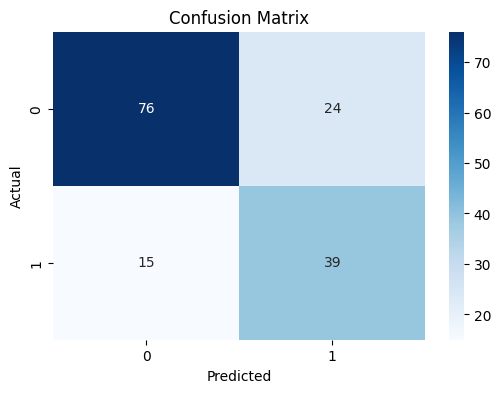

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

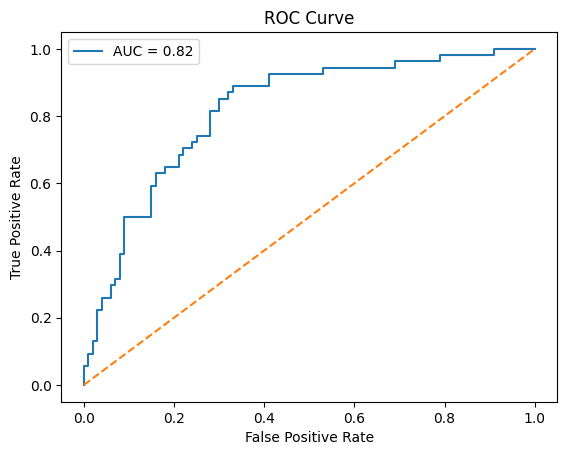

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

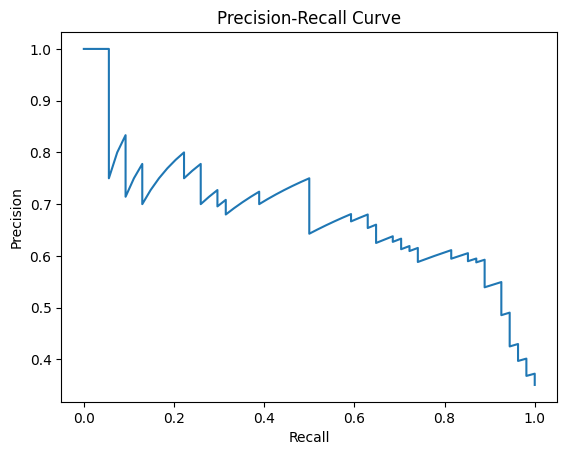

In [ ]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
print(f"AUC Score: {roc_auc:.2f}")

AUC Score: 0.82


In [ ]:
df_fe = df.copy()
# your new features

In [ ]:
X = df_fe.drop("Outcome", axis=1)
y = df_fe["Outcome"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [ ]:
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

/home/acer/Downloads/credit-card-fraud-detection/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return {
    "Model": name,
    "Accuracy": round(acc, 2),
    "Precision (Diabetic)": round(precision, 2),
    "Recall (Diabetic)": round(recall, 2),
    "F1 Score": round(f1, 2)
}

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000   
)

log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
results = []

results.append(evaluate_model("Logistic Regression", log_model, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_model, X_test, y_test))
results.append(evaluate_model("XGBoost", xgb_model, X_test, y_test))

comparison_df = pd.DataFrame(results)

# reorder columns explicitly
comparison_df = comparison_df[
    ["Model", "Accuracy", "Precision (Diabetic)", "Recall (Diabetic)", "F1 Score"]
]

print(comparison_df)

                 Model  Accuracy  Precision (Diabetic)  Recall (Diabetic)  \
0  Logistic Regression      0.73                  0.59               0.70   
1        Random Forest      0.76                  0.67               0.61   
2              XGBoost      0.75                  0.62               0.72   

   F1 Score  
0      0.64  
1      0.64  
2      0.67  


In [ ]:
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)
print(comparison_df)

                 Model  Accuracy  Precision (Diabetic)  Recall (Diabetic)  \
2              XGBoost      0.75                  0.62               0.72   
0  Logistic Regression      0.73                  0.59               0.70   
1        Random Forest      0.76                  0.67               0.61   

   F1 Score  
2      0.67  
0      0.64  
1      0.64  


In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',  
    cv=5,
    verbose=1,
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 150], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [ ]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [ ]:
best_xgb = grid_search.best_estimator_

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_tuned = best_xgb.predict(X_test)

print("Tuned XGBoost Report:\n")
print(classification_report(y_test, y_pred_tuned))

Tuned XGBoost Report:

              precision    recall  f1-score   support

           0       0.80      0.81      0.81       100
           1       0.64      0.63      0.64        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [ ]:
results.append(evaluate_model("XGBoost Tuned", best_xgb, X_test, y_test))

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

print(comparison_df)

                 Model  Accuracy  Precision (Diabetic)  Recall (Diabetic)  \
2              XGBoost      0.75                  0.62               0.72   
0  Logistic Regression      0.73                  0.59               0.70   
1        Random Forest      0.76                  0.67               0.61   
3        XGBoost Tuned      0.75                  0.64               0.63   
4        XGBoost Tuned      0.75                  0.64               0.63   

   F1 Score  
2      0.67  
0      0.64  
1      0.64  
3      0.64  
4      0.64  


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# reusable function
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 2),
        "Precision (Diabetic)": round(precision_score(y_true, y_pred), 2),
        "Recall (Diabetic)": round(recall_score(y_true, y_pred), 2),
        "F1 Score": round(f1_score(y_true, y_pred), 2)
    }


results = []

# Logistic Regression
y_pred_log = log_model.predict(X_test)
results.append(evaluate_model("Logistic Regression", y_test, y_pred_log))

# Random Forest
y_pred_rf = rf_model.predict(X_test)
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))

# XGBoost (default)
y_pred_xgb = xgb_model.predict(X_test)
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb))

#  XGBoost + Threshold (BEST MODEL)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_prob_xgb > 0.30).astype(int)   # use your best threshold
results.append(evaluate_model("XGBoost (Threshold=0.30)", y_test, y_pred_thresh))


# Create dataframe
comparison_df = pd.DataFrame(results)

# Sort by best model
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

# Reset index (clean look)
comparison_df = comparison_df.reset_index(drop=True)

print(comparison_df)

                      Model  Accuracy  Precision (Diabetic)  \
0  XGBoost (Threshold=0.30)      0.74                  0.59   
1                   XGBoost      0.75                  0.62   
2             Random Forest      0.76                  0.67   
3       Logistic Regression      0.73                  0.59   

   Recall (Diabetic)  F1 Score  
0               0.89      0.71  
1               0.72      0.67  
2               0.61      0.64  
3               0.70      0.64  


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 2),
        "Precision (Diabetic)": round(precision_score(y_true, y_pred), 2),
        "Recall (Diabetic)": round(recall_score(y_true, y_pred), 2),
        "F1 Score": round(f1_score(y_true, y_pred), 2),
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 2)
    }

In [ ]:
results = []

# Logistic Regression
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]
results.append(evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log))


# Random Forest
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf))


# XGBoost
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb))


#  XGBoost + Threshold
y_pred_thresh = (y_prob_xgb > 0.30).astype(int)
results.append(evaluate_model("XGBoost (Threshold=0.30)", y_test, y_pred_thresh, y_prob_xgb))


# Create table
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print(comparison_df)

                      Model  Accuracy  Precision (Diabetic)  \
0  XGBoost (Threshold=0.30)      0.74                  0.59   
1                   XGBoost      0.75                  0.62   
2             Random Forest      0.76                  0.67   
3       Logistic Regression      0.73                  0.59   

   Recall (Diabetic)  F1 Score  ROC-AUC  
0               0.89      0.71     0.82  
1               0.72      0.67     0.82  
2               0.61      0.64     0.82  
3               0.70      0.64     0.81  


In [ ]:
import joblib

# save model
joblib.dump(xgb_model, "../model/xgb_model.pkl")

# load later
# model = joblib.load("../model/xgb_model.pkl")

['../model/xgb_model.pkl']

In [ ]:
best_threshold = 0.30

joblib.dump(best_threshold, "../model/threshold.pkl")

['../model/threshold.pkl']

In [ ]:
import joblib

# Save feature order (VERY IMPORTANT)
joblib.dump(X.columns.tolist(), "../model/feature_order.pkl")

print("feature_order.pkl saved successfully!")

feature_order.pkl saved successfully!
